# Efficient VLM Inference via Visual Token Compression

Colab demo for Qwen2.5-VL / Qwen2-VL inference-time visual token compression benchmarks.

## 1. Install dependencies

Use an A100 runtime when possible. Colab normally ships with a CUDA-matched PyTorch build, so the torch install line is kept as an optional fallback.

In [1]:
try:
    import torch
except ImportError:
    %pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu124

%pip install -q -U torchvision transformers accelerate qwen-vl-utils datasets pillow pandas matplotlib tqdm psutil pynvml pyyaml

# If you see KeyError: 'qwen2_5_vl' or 'qwen2_vl', run this and restart runtime:
# %pip install -q -U git+https://github.com/huggingface/transformers accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1

## 2. Clone repo and move to project root

This clones the public GitHub repo into Colab and adds the repo root to `sys.path`, so imports like `from src.compression import create_compression_method` work.

In [2]:
import os
import subprocess
import sys

REPO_URL = "https://github.com/YuqiWang26/vlm.git"
PROJECT_DIR = "/content/vlm"

if not os.path.exists(PROJECT_DIR):
    subprocess.run(["git", "clone", REPO_URL, PROJECT_DIR], check=True)
else:
    subprocess.run(["git", "-C", PROJECT_DIR, "pull", "--ff-only"], check=False)

os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

print("Current directory:", os.getcwd())
print("Repo root added to sys.path:", PROJECT_DIR)

Current directory: /content/vlm
Repo root added to sys.path: /content/vlm


## 3. Check GPU

In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print("Memory GB:", round(props.total_memory / 1024**3, 1))
!nvidia-smi

PyTorch: 2.10.0+cu128
CUDA: 12.8
CUDA available: True
GPU: Tesla T4
Memory GB: 14.6
Fri May  1 19:29:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |             

## 4. Smoke test compression functions without loading the VLM

In [4]:
import torch
from src.compression import create_compression_method

device = "cuda" if torch.cuda.is_available() else "cpu"
tokens = torch.randn(1, 64, 128, device=device)
for name in ["none", "fixed", "importance", "merging"]:
    method = create_compression_method(name, retention_ratio=0.5, apply_proxy_image_budget=False)
    compressed = method.compress_visual_tokens(tokens).tokens
    print(name, tuple(tokens.shape), "->", tuple(compressed.shape))

none (1, 64, 128) -> (1, 64, 128)
fixed (1, 64, 128) -> (1, 32, 128)
importance (1, 64, 128) -> (1, 32, 128)
merging (1, 64, 128) -> (1, 32, 128)


## 5. Quick benchmark

This loads the model and runs a synthetic stress benchmark with OCR, counting, table lookup, and spatial-reference questions. On A100, start with Qwen2.5-VL-3B. If model download or memory is a problem, use the Qwen2-VL-2B fallback cell.

In [5]:
!python run_benchmark.py --quick --model-id Qwen/Qwen2.5-VL-3B-Instruct --dtype fp16 --attn-implementation eager --methods none,fixed,importance,merging --ratios 1.0,0.75,0.5,0.25,0.1,0.05 --samples 12 --no-plots

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Python executable: /usr/bin/python3
PyTorch: 2.11.0+cu130
CUDA available: True
CUDA version: 13.0
GPU 0: Tesla T4 | 14.6 GB
NVML GPU 0: Tesla T4 | used 600.2 MB
Fri May  1 19:30:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                             

In [6]:
# Fallback option:
# !python run_benchmark.py --quick --model-id Qwen/Qwen2-VL-2B-Instruct --dtype fp16 --attn-implementation eager --methods none,fixed,importance,merging --ratios 1.0,0.75,0.5,0.25,0.1,0.05 --samples 12 --no-plots

## 6. Full benchmark

In [7]:
# This can take a while. Reduce --samples or remove high/4-image settings if needed.
# !python run_benchmark.py \
#   --model-id Qwen/Qwen2.5-VL-3B-Instruct \
#   --dtype fp16 \
#   --attn-implementation eager \
#   --methods none,fixed,importance,merging \
#   --ratios 1.0,0.75,0.5,0.25,0.1,0.05 \
#   --resolutions low,medium,high \
#   --num-images 1,2,4 \
#   --samples 6 \
#   --max-new-tokens 64 \
#   --no-plots

## 7. View results and plots

,model_id,compression_method,retention_ratio,input_resolution,num_images,max_new_tokens,sample_id,question,reference_answer,keywords,...,throughput_tokens_per_second,generated_tokens,quality_score,number_of_visual_tokens,original_visual_tokens,kept_visual_tokens,compression_applied_internal,original_seq_len,compressed_seq_len,prepared_image_sizes
0,Qwen/Qwen2.5-VL-3B-Instruct,none,1.0,medium,1,32,small_corner_code,Read the codes in the blue label and the yello...,m2q8 k7p4,"m2q8,k7p4",...,8.691240,9,1.0,529,529,529,False,NaN,NaN,"[(644, 644)]"
1,Qwen/Qwen2.5-VL-3B-Instruct,none,1.0,medium,1,32,receipt_total,What are the TAX and TOTAL amounts printed on ...,1.35 13.10,"1.35,13.10",...,8.636196,12,1.0,529,529,529,False,NaN,NaN,"[(644, 644)]"
2,Qwen/Qwen2.5-VL-3B-Instruct,none,1.0,medium,1,32,blue_dot_count,How many blue dots and red dots are in the gri...,7 5,"7,5",...,5.171370,5,0.0,529,529,529,False,NaN,NaN,"[(644, 644)]"
3,Qwen/Qwen2.5-VL-3B-Instruct,none,1.0,medium,1,32,chart_value_lookup,Which colored bar has the largest printed valu...,purple 17,"purple,17",...,6.057593,6,1.0,529,529,529,False,NaN,NaN,"[(644, 644)]"
4,Qwen/Qwen2.5-VL-3B-Instruct,none,1.0,medium,1,32,left_of_star_label,What labels are under the objects immediately ...,b2 d4,"b2,d4",...,6.656257,6,1.0,529,529,529,False,NaN,NaN,"[(644, 644)]"


,compression_method,retention_ratio,avg_latency,avg_memory,avg_quality_score,avg_throughput,avg_visual_tokens,num_runs,success_rate
0,fixed,0.05,971.411593,7772.738607,0.000000,9.310966,26.0,12,1.0
1,fixed,0.10,937.861099,7772.738607,0.250000,8.972154,53.0,12,1.0
2,fixed,0.25,892.023215,7772.738607,0.500000,8.687024,132.0,12,1.0
3,fixed,0.50,964.842965,7772.738607,0.750000,8.167337,264.0,12,1.0
4,fixed,0.75,1036.900232,7772.738607,0.833333,7.960829,397.0,12,1.0
5,fixed,1.00,1078.334070,7772.749430,0.833333,7.459728,529.0,12,1.0
6,importance,0.05,603.084254,7179.977539,0.083333,15.041465,25.0,12,1.0
7,importance,0.10,499.379973,7182.753011,0.250000,15.904563,49.0,12,1.0
8,importance,0.25,616.875043,7212.041504,0.833333,13.413031,121.0,12,1.0
9,importance,0.50,748.122790,7326.106527,0.833333,11.261131,256.0,12,1.0


,compression_method,retention_ratio,latency_ms,memory_mb,quality_score,throughput,exact_match_score,all_keywords_score,num_runs
0,fixed,0.05,971.411593,7772.738607,0.000000,9.310966,0.000000,0.000000,12
1,fixed,0.10,937.861099,7772.738607,0.250000,8.972154,0.166667,0.250000,12
2,fixed,0.25,892.023215,7772.738607,0.500000,8.687024,0.333333,0.500000,12
3,fixed,0.50,964.842965,7772.738607,0.750000,8.167337,0.666667,0.750000,12
4,fixed,0.75,1036.900232,7772.738607,0.833333,7.960829,0.666667,0.833333,12
5,fixed,1.00,1078.334070,7772.749430,0.833333,7.459728,0.666667,0.833333,12
6,importance,0.05,603.084254,7179.977539,0.083333,15.041465,0.083333,0.083333,12
7,importance,0.10,499.379973,7182.753011,0.250000,15.904563,0.250000,0.250000,12
8,importance,0.25,616.875043,7212.041504,0.833333,13.413031,0.666667,0.833333,12
9,importance,0.50,748.122790,7326.106527,0.833333,11.261131,0.666667,0.833333,12


,compression_method,retention_ratio,latency_ms,latency_reduction_pct,memory_mb,memory_reduction_pct,quality_score,quality_delta_points,exact_match_score,all_keywords_score,num_runs
0,fixed,0.05,971.411593,6.794252,7772.738607,0.000139,0.000000,-83.333333,0.000000,0.000000,12
1,fixed,0.10,937.861099,10.013380,7772.738607,0.000139,0.250000,-58.333333,0.166667,0.250000,12
2,fixed,0.25,892.023215,14.411469,7772.738607,0.000139,0.500000,-33.333333,0.333333,0.500000,12
3,fixed,0.50,964.842965,7.424503,7772.738607,0.000139,0.750000,-8.333333,0.666667,0.750000,12
4,fixed,0.75,1036.900232,0.510697,7772.738607,0.000139,0.833333,0.000000,0.666667,0.833333,12
5,fixed,1.00,1078.334070,-3.464829,7772.749430,0.000000,0.833333,0.000000,0.666667,0.833333,12
6,importance,0.05,603.084254,42.134807,7179.977539,7.626283,0.083333,-75.000000,0.083333,0.083333,12
7,importance,0.10,499.379973,52.085105,7182.753011,7.590576,0.250000,-58.333333,0.250000,0.250000,12
8,importance,0.25,616.875043,40.811598,7212.041504,7.213766,0.833333,0.000000,0.666667,0.833333,12
9,importance,0.50,748.122790,28.218538,7326.106527,5.746267,0.833333,0.000000,0.666667,0.833333,12


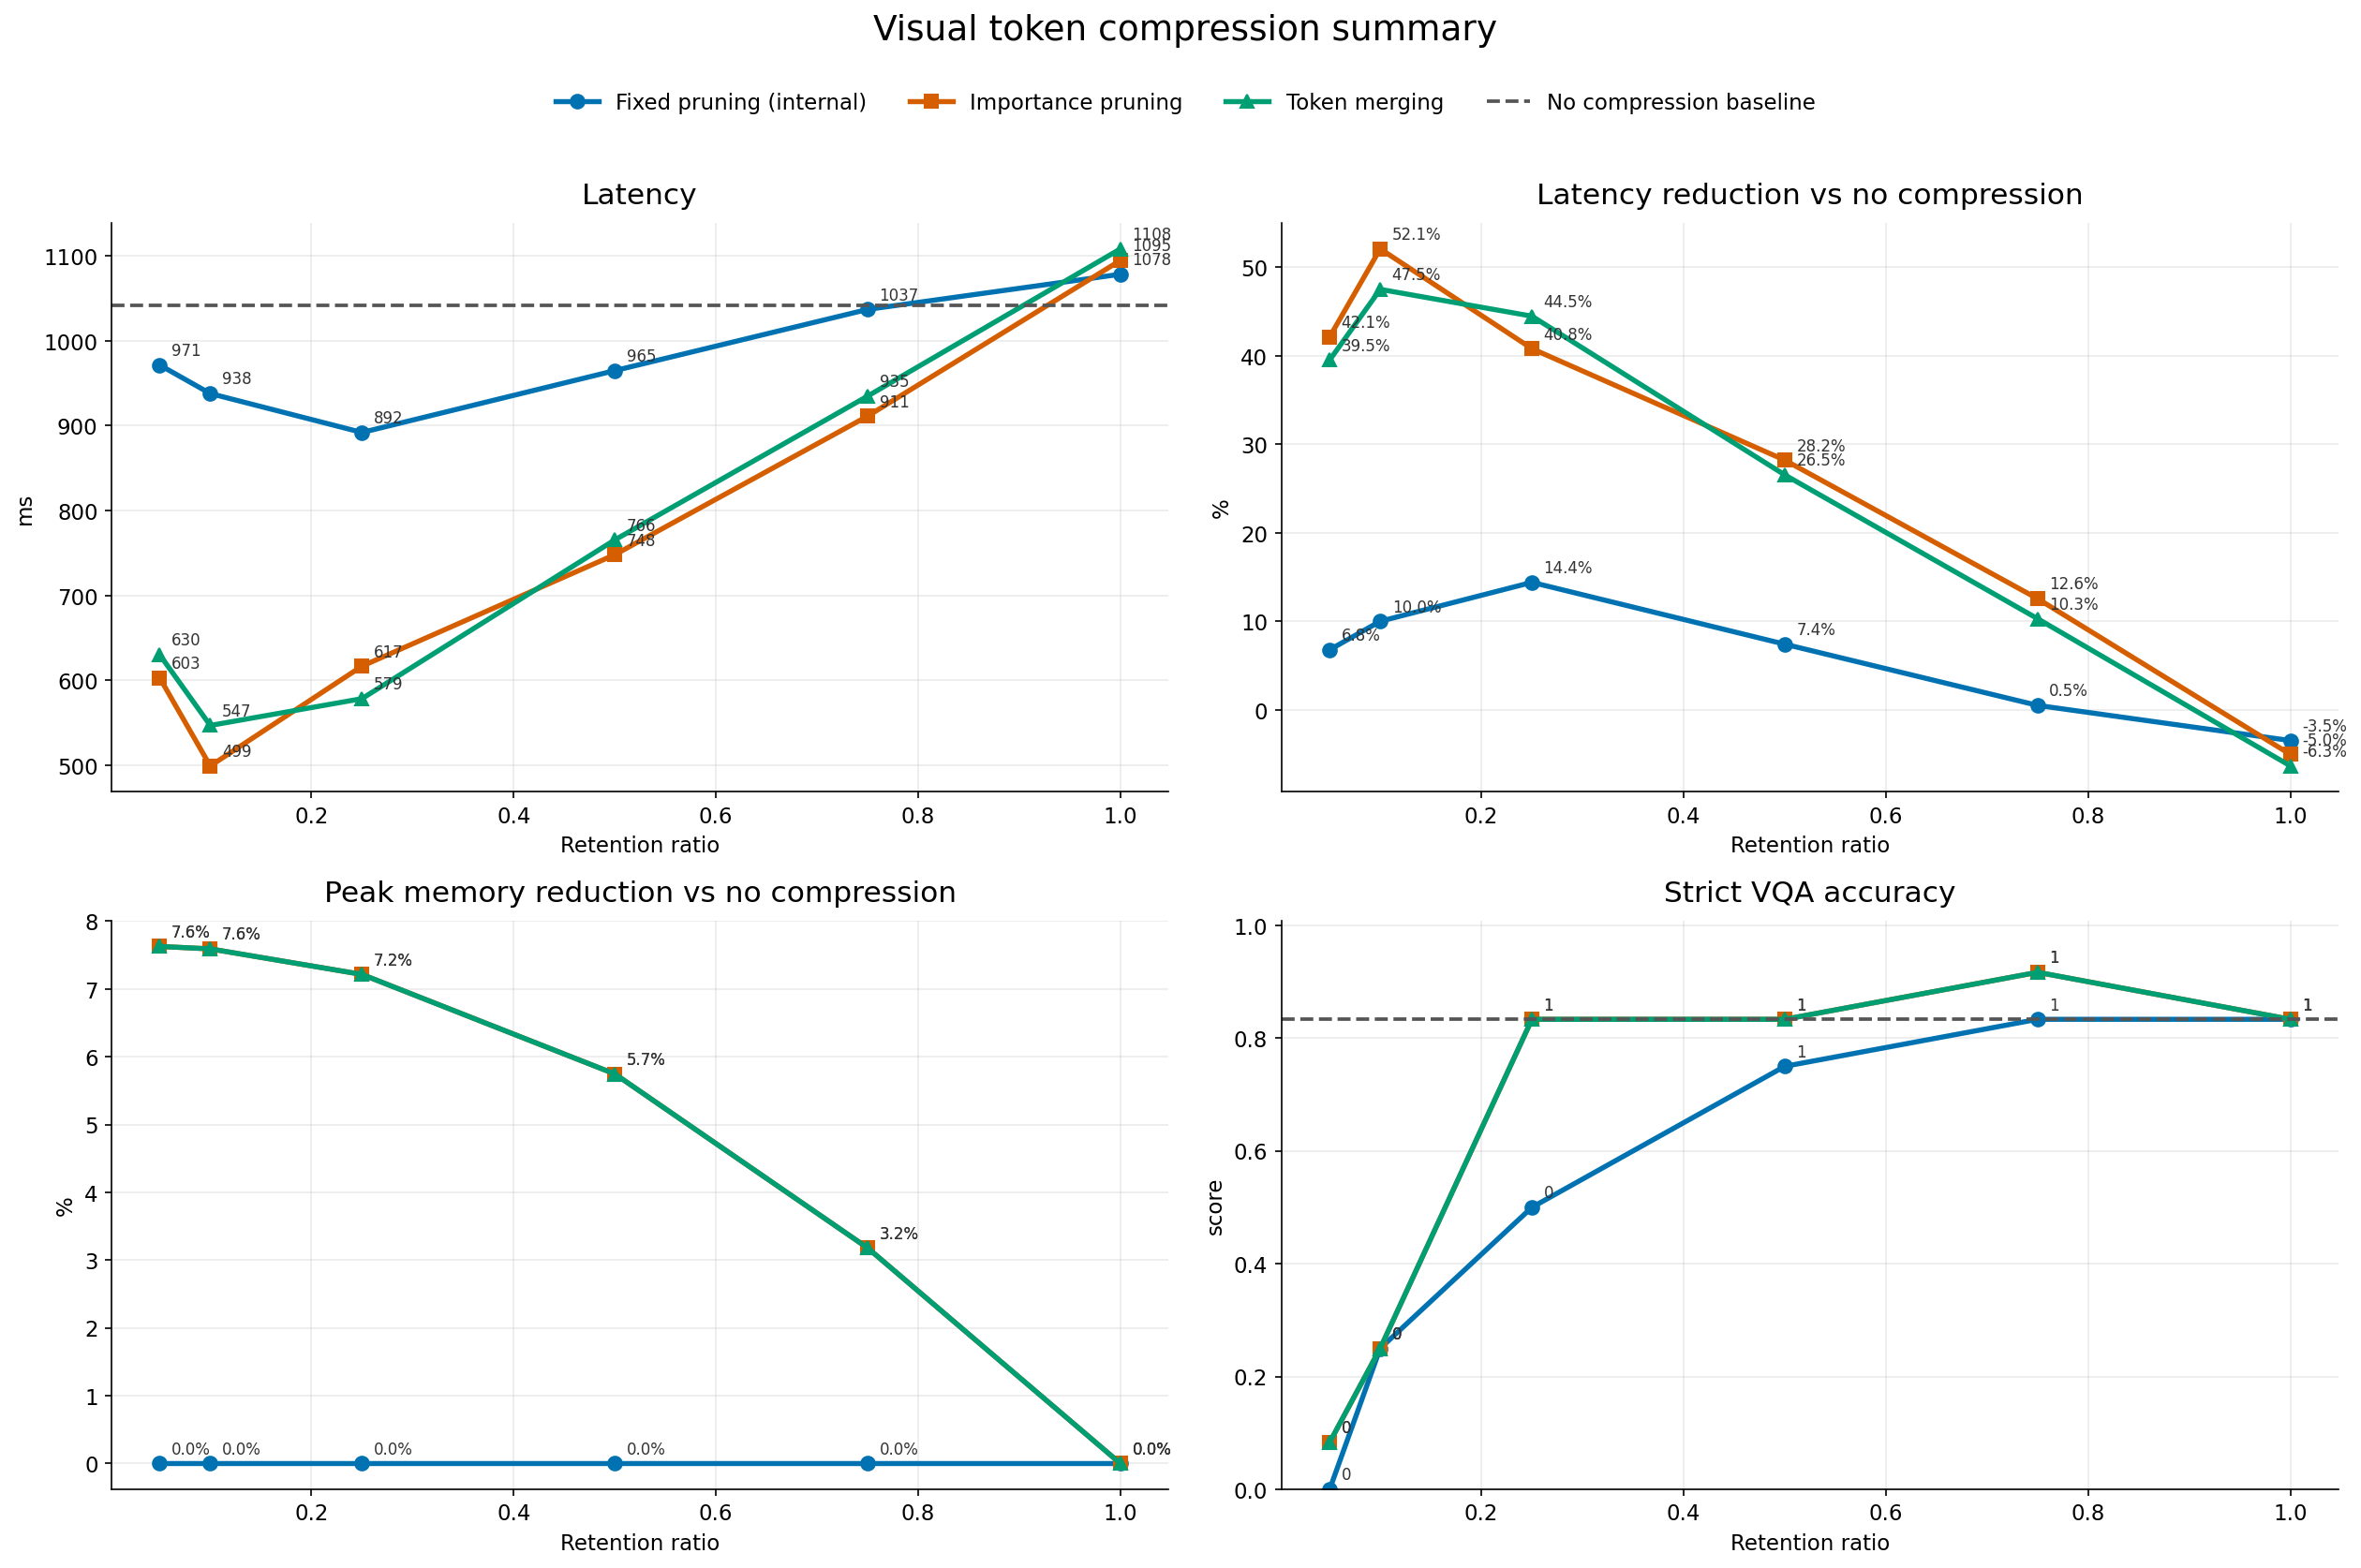

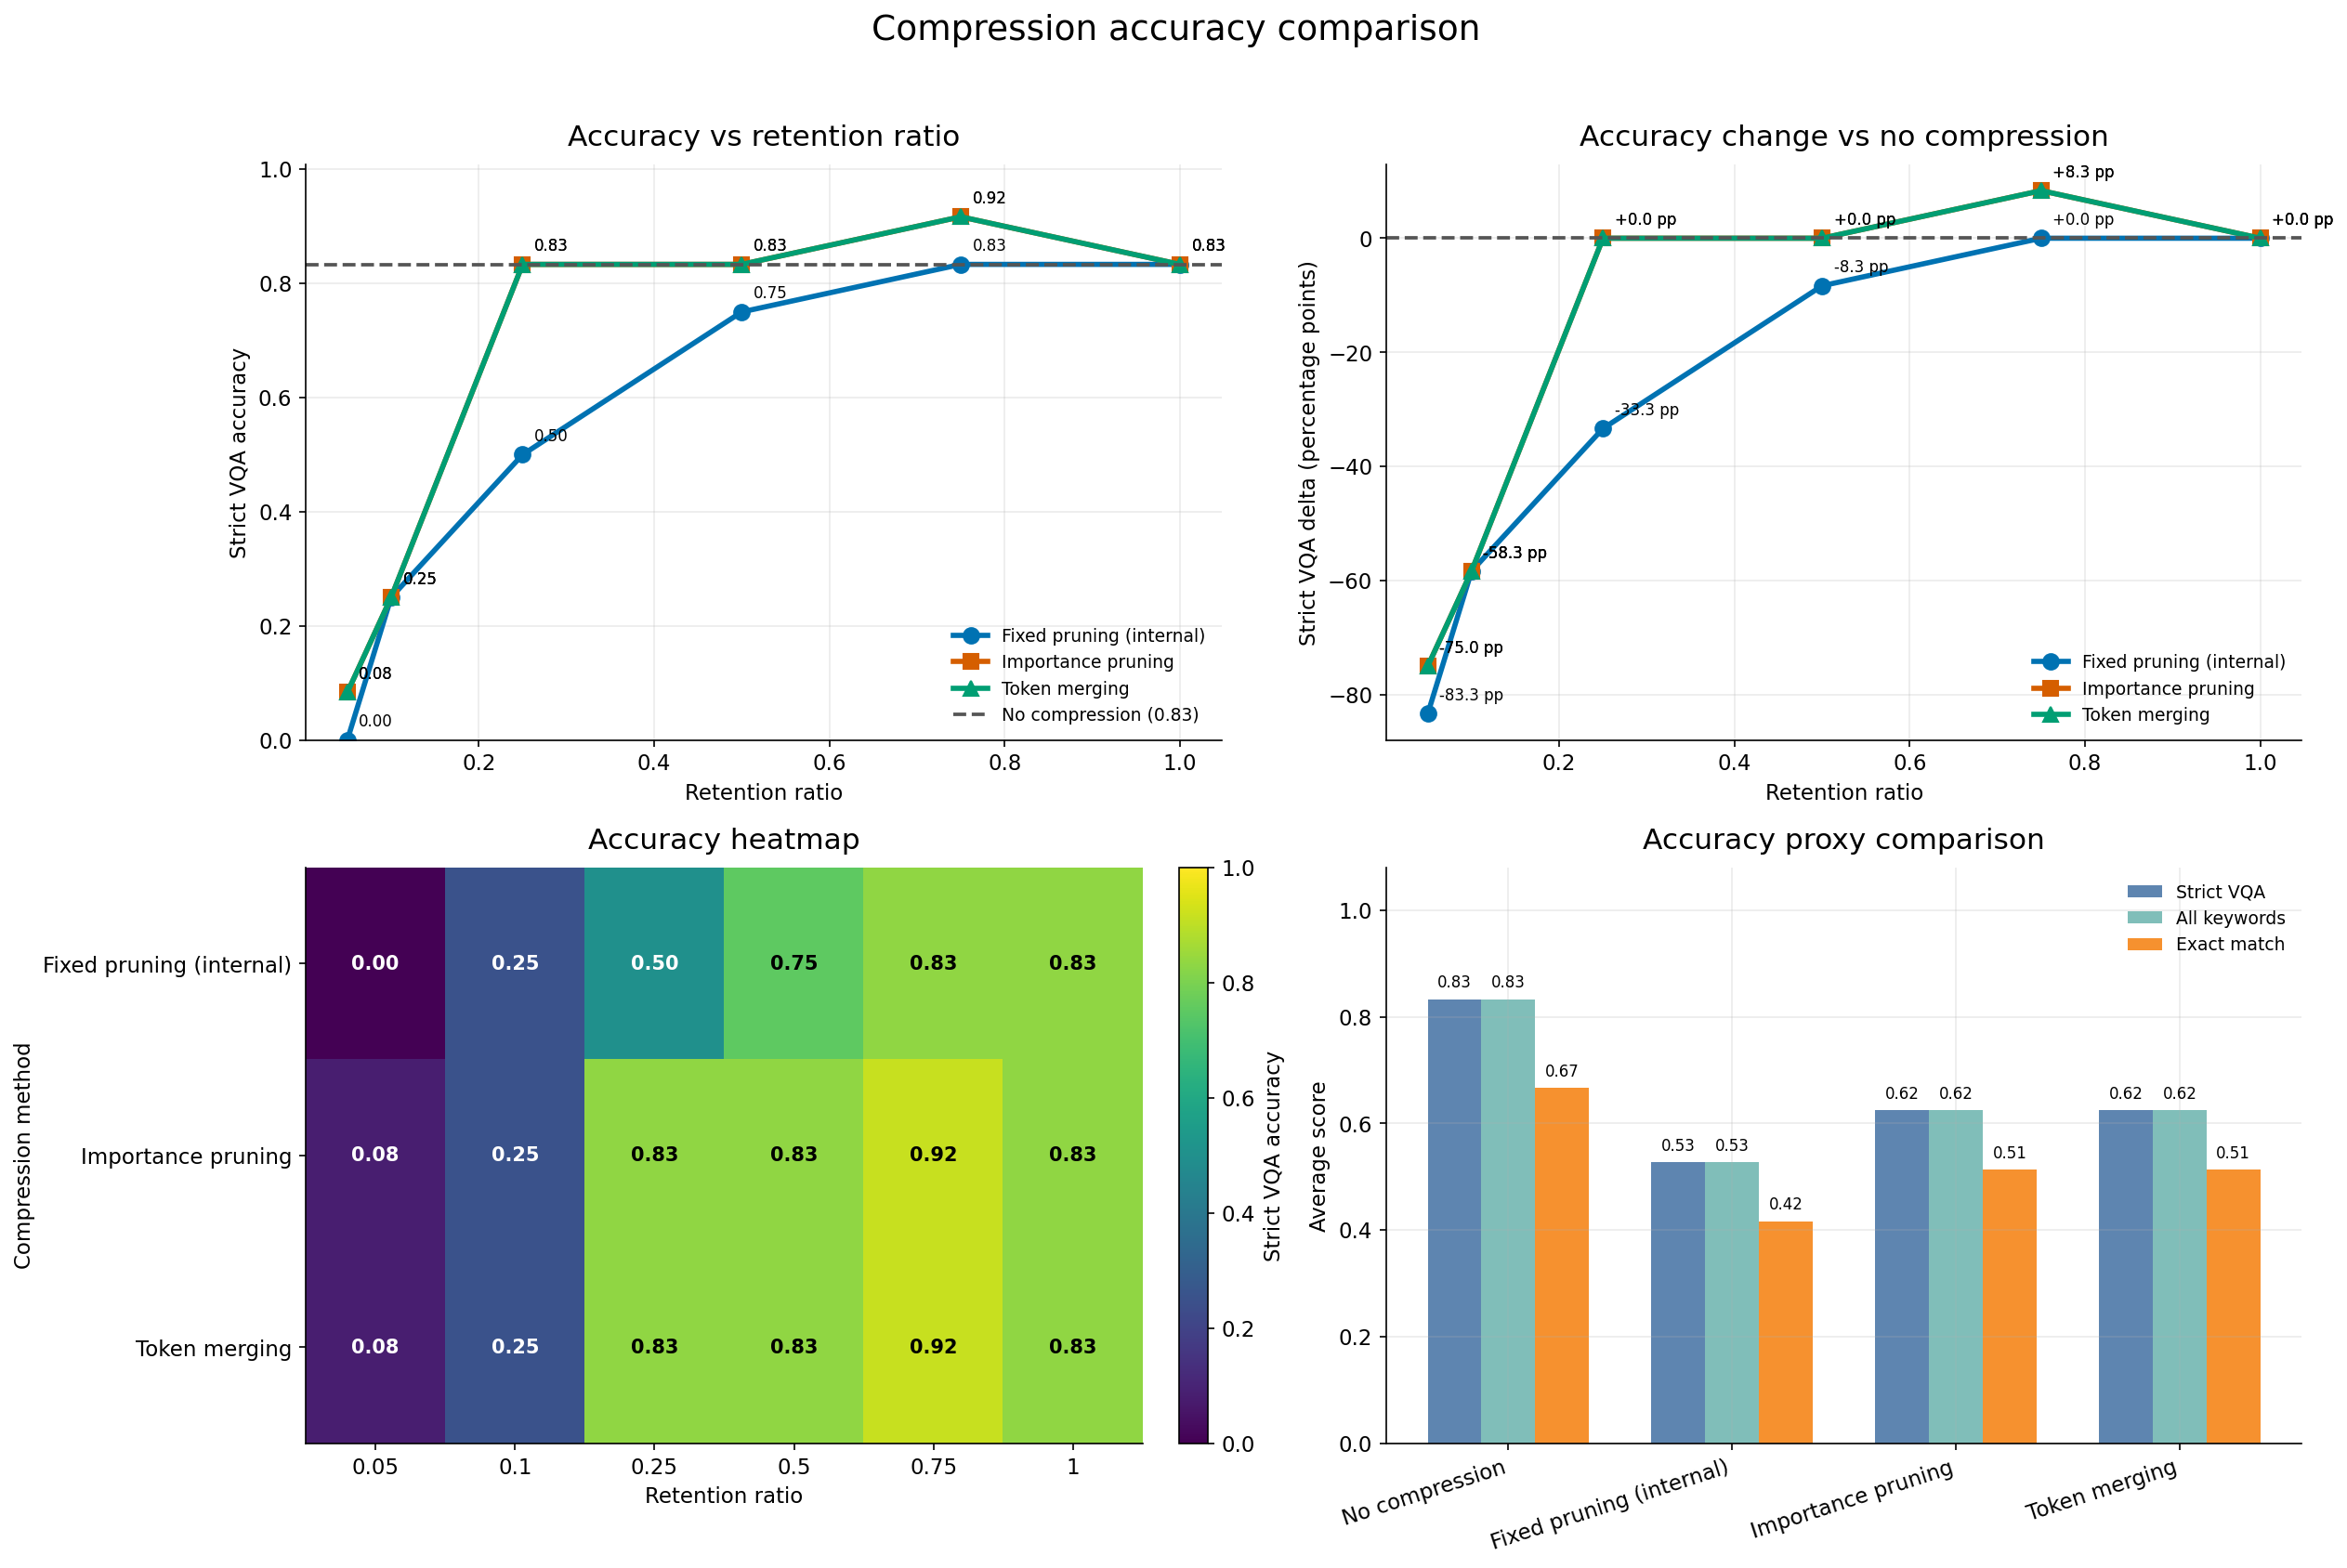

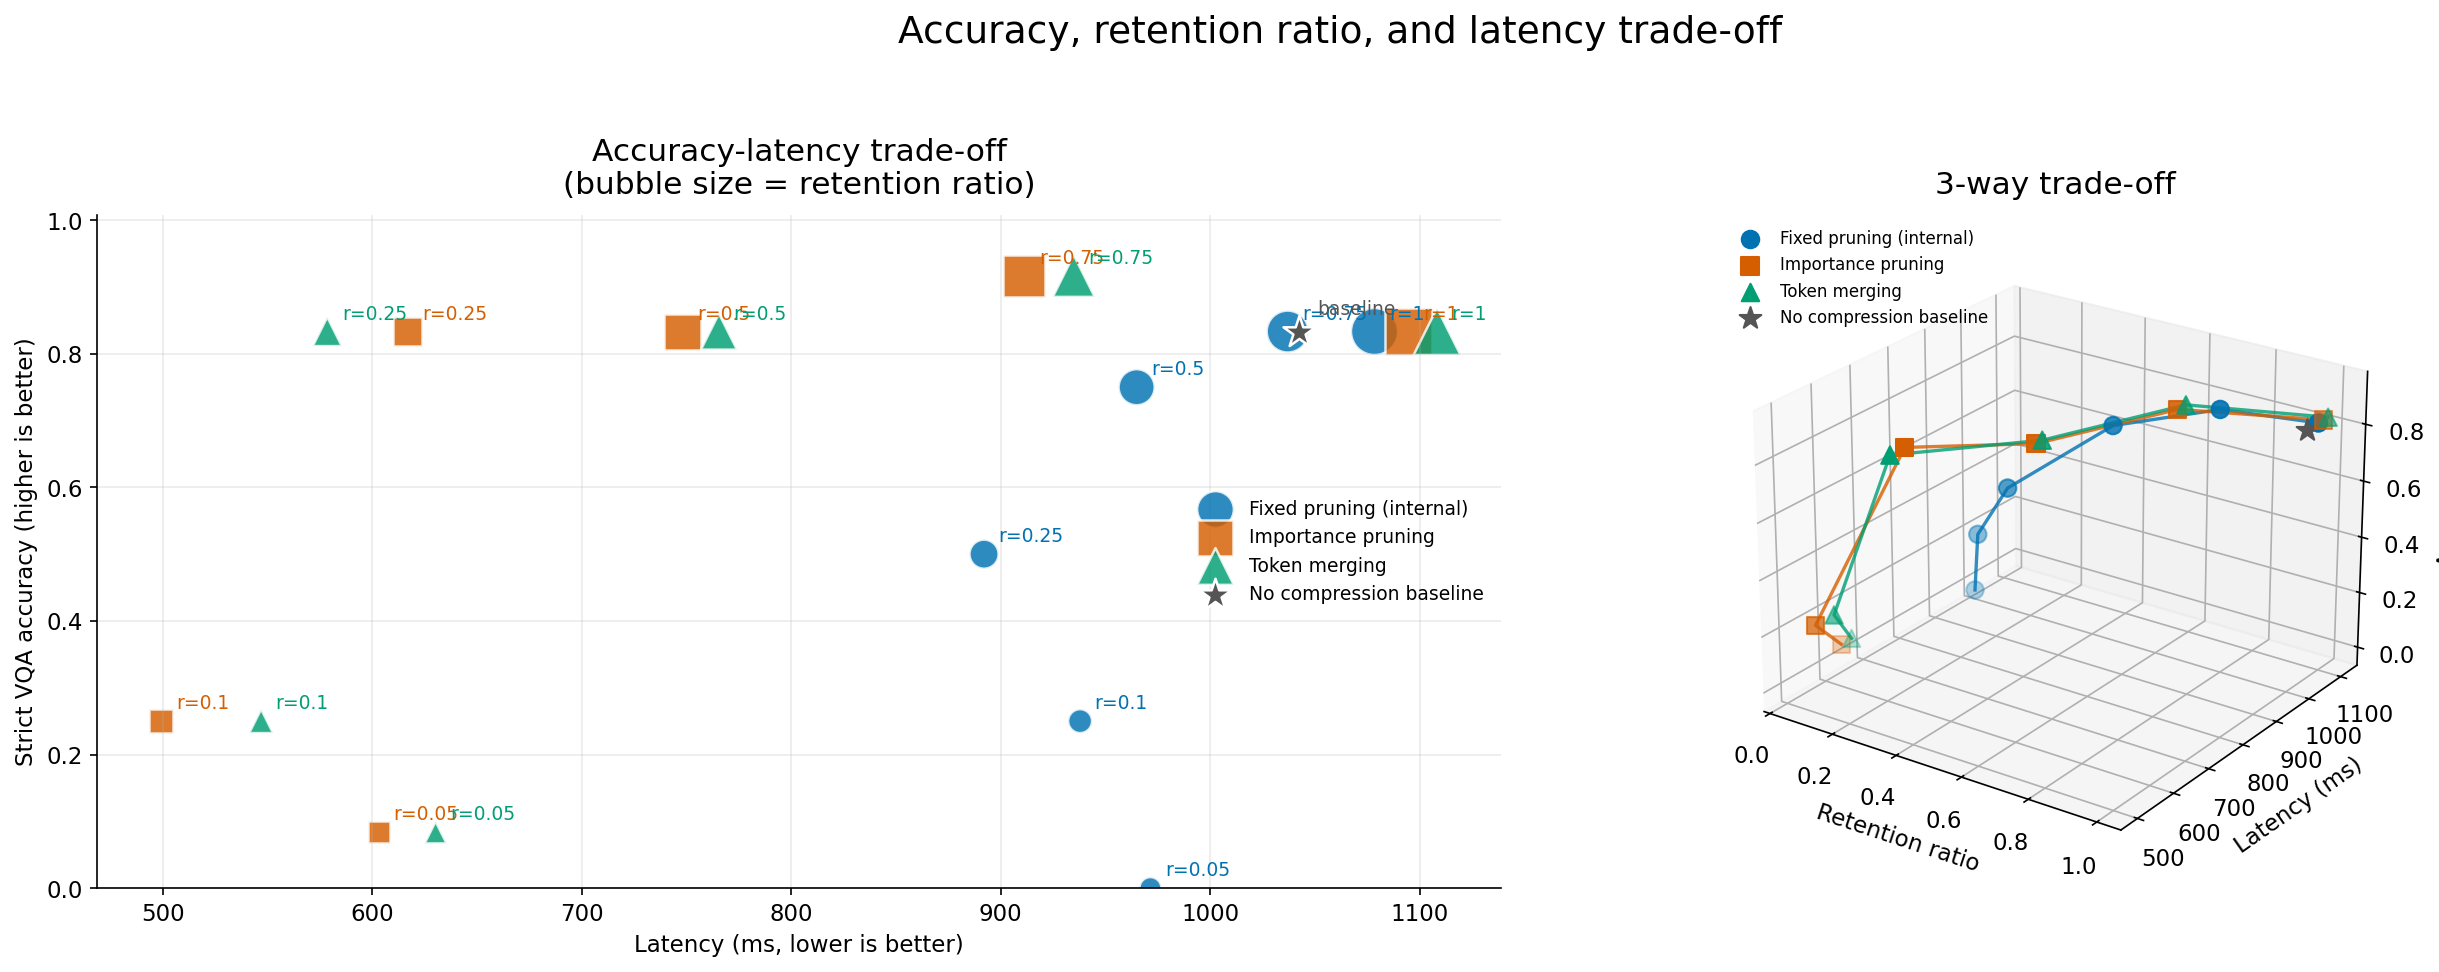

Saved plots:
 - results/notebook_tradeoff_summary.png
 - results/notebook_accuracy_comparison.png
 - results/notebook_accuracy_latency_retention_tradeoff.png


In [8]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

raw_path = "results/benchmark_results.csv"
summary_path = "results/summary_results.csv"

if not os.path.exists(raw_path):
    raise FileNotFoundError("Run the quick benchmark cell before viewing results.")

raw_df = pd.read_csv(raw_path)
display(raw_df.head())

if os.path.exists(summary_path):
    display(pd.read_csv(summary_path))

if "success" in raw_df.columns and not raw_df["success"].astype(bool).any():
    print("No successful benchmark rows. First errors:")
    error_cols = [col for col in ["compression_method", "retention_ratio", "oom", "error"] if col in raw_df.columns]
    display(raw_df[error_cols].head(10))

success_df = raw_df[raw_df["success"].astype(bool)].copy() if "success" in raw_df.columns else raw_df.copy()
if success_df.empty:
    raise RuntimeError("No successful benchmark rows to plot. Check the error column above.")

# The benchmark uses a strict all-keywords VQA score by default.
# This cell also derives exact-match and all-keyword binary scores when answers/keywords exist,
# so the accuracy plots are easier to compare across compression methods.
def _normalize_answer(text):
    text = "" if pd.isna(text) else str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return " ".join(text.split())

def _compact_answer(text):
    return _normalize_answer(text).replace(" ", "")

def _contains_keyword(answer, keyword):
    answer_norm = _normalize_answer(answer)
    keyword_norm = _normalize_answer(keyword)
    if not keyword_norm:
        return False
    answer_tokens = answer_norm.split()
    keyword_tokens = keyword_norm.split()
    if len(keyword_tokens) == 1 and keyword_tokens[0].isdigit() and len(keyword_tokens[0]) <= 2:
        return keyword_tokens[0] in answer_tokens
    if len(keyword_tokens) == 1 and keyword_tokens[0] in answer_tokens:
        return True
    if f" {keyword_norm} " in f" {answer_norm} ":
        return True
    return bool(_compact_answer(keyword) and _compact_answer(keyword) in _compact_answer(answer))

def _keyword_list(value):
    if pd.isna(value):
        return []
    return [_normalize_answer(k) for k in str(value).split(",") if _normalize_answer(k)]

def _all_keyword_score(row):
    keywords = _keyword_list(row.get("keywords", ""))
    if not keywords:
        return np.nan
    answer = row.get("generated_answer", "")
    return float(all(_contains_keyword(answer, keyword) for keyword in keywords))

def _exact_match_score(row):
    if "generated_answer" not in row or "reference_answer" not in row:
        return np.nan
    reference = _normalize_answer(row.get("reference_answer", ""))
    if not reference:
        return np.nan
    answer = row.get("generated_answer", "")
    return float(_normalize_answer(answer) == reference or _compact_answer(answer) == _compact_answer(reference))

success_df["exact_match_score"] = success_df.apply(_exact_match_score, axis=1)
success_df["all_keywords_score"] = success_df.apply(_all_keyword_score, axis=1)

agg_spec = {
    "latency_ms": ("latency_ms", "mean"),
    "memory_mb": ("peak_gpu_memory_mb", "mean"),
    "quality_score": ("quality_score", "mean"),
    "throughput": ("throughput_tokens_per_second", "mean"),
    "exact_match_score": ("exact_match_score", "mean"),
    "all_keywords_score": ("all_keywords_score", "mean"),
    "num_runs": ("sample_id", "count"),
}

grouped = (
    success_df.groupby(["compression_method", "retention_ratio"], as_index=False)
    .agg(**agg_spec)
    .sort_values(["compression_method", "retention_ratio"])
)
display(grouped)

method_order = ["fixed", "importance", "merging"]
colors = {"fixed": "#0072B2", "importance": "#D55E00", "merging": "#009E73", "none": "#555555"}
labels = {"fixed": "Fixed pruning (internal)", "importance": "Importance pruning", "merging": "Token merging", "none": "No compression"}
markers = {"fixed": "o", "importance": "s", "merging": "^"}

baseline_rows = grouped[grouped["compression_method"] == "none"].copy()
if not baseline_rows.empty:
    exact_baseline = baseline_rows[np.isclose(baseline_rows["retention_ratio"], 1.0)]
    baseline = exact_baseline.iloc[0] if not exact_baseline.empty else baseline_rows.iloc[0]
else:
    baseline = None

plot_df = grouped[grouped["compression_method"] != "none"].copy()
if baseline is not None:
    plot_df["latency_reduction_pct"] = (baseline["latency_ms"] - plot_df["latency_ms"]) / baseline["latency_ms"] * 100
    plot_df["memory_reduction_pct"] = (baseline["memory_mb"] - plot_df["memory_mb"]) / baseline["memory_mb"] * 100
    plot_df["quality_delta_points"] = (plot_df["quality_score"] - baseline["quality_score"]) * 100
    plot_df["quality_retained_pct"] = plot_df["quality_score"] / max(float(baseline["quality_score"]), 1e-9) * 100
else:
    plot_df["latency_reduction_pct"] = np.nan
    plot_df["memory_reduction_pct"] = np.nan
    plot_df["quality_delta_points"] = np.nan
    plot_df["quality_retained_pct"] = np.nan

display(plot_df[[
    "compression_method", "retention_ratio", "latency_ms", "latency_reduction_pct",
    "memory_mb", "memory_reduction_pct", "quality_score", "quality_delta_points",
    "exact_match_score", "all_keywords_score", "num_runs"
]].sort_values(["compression_method", "retention_ratio"]))

os.makedirs("results", exist_ok=True)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

def _axis_quality_bounds(values):
    values = pd.Series(values).dropna().astype(float)
    if values.empty:
        return 0.0, 1.05
    vmin, vmax = float(values.min()), float(values.max())
    if abs(vmax - vmin) < 0.02:
        return max(0.0, vmin - 0.06), min(1.06, vmax + 0.06)
    margin = max(0.03, 0.10 * (vmax - vmin))
    return max(0.0, vmin - margin), min(1.06, vmax + margin)

quality_low, quality_high = _axis_quality_bounds(pd.concat([grouped["quality_score"], grouped["all_keywords_score"], grouped["exact_match_score"]]))

# -------------------------------------------------------------------------
# Figure 1: compact efficiency summary
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(17, 10.5), dpi=150)
axes = axes.ravel()

def plot_line_metric(ax, y_col, title, ylabel, baseline_col=None, percent=False):
    for method in method_order:
        sub = plot_df[plot_df["compression_method"] == method].sort_values("retention_ratio")
        if sub.empty or sub[y_col].dropna().empty:
            continue
        ax.plot(
            sub["retention_ratio"], sub[y_col],
            marker=markers[method], linewidth=2.6, markersize=7,
            color=colors[method], label=labels[method],
        )
        for _, row in sub.iterrows():
            value = row[y_col]
            if pd.isna(value):
                continue
            text = f"{value:.1f}%" if percent else f"{value:.0f}"
            ax.annotate(text, (row["retention_ratio"], value), xytext=(6, 5), textcoords="offset points", fontsize=8, color="#333333")
    if baseline is not None and baseline_col is not None:
        ax.axhline(baseline[baseline_col], color=colors["none"], linestyle="--", linewidth=1.8, label="No compression baseline")
    ax.set_title(title, fontsize=15, pad=10)
    ax.set_xlabel("Retention ratio")
    ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)

plot_line_metric(axes[0], "latency_ms", "Latency", "ms", baseline_col="latency_ms")
plot_line_metric(axes[1], "latency_reduction_pct", "Latency reduction vs no compression", "%", percent=True)
plot_line_metric(axes[2], "memory_reduction_pct", "Peak memory reduction vs no compression", "%", percent=True)
plot_line_metric(axes[3], "quality_score", "Strict VQA accuracy", "score", baseline_col="quality_score")
axes[3].set_ylim(quality_low, quality_high)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=4, frameon=False, fontsize=11, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Visual token compression summary", fontsize=18, y=1.06)
fig.tight_layout()
summary_plot_path = "results/notebook_tradeoff_summary.png"
fig.savefig(summary_plot_path, bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------------
# Figure 2: accuracy-focused comparison across methods
# -------------------------------------------------------------------------
fig2, axes2 = plt.subplots(2, 2, figsize=(17, 11), dpi=150)
axes2 = axes2.ravel()

# A) Accuracy vs retention ratio
ax = axes2[0]
for method in method_order:
    sub = plot_df[plot_df["compression_method"] == method].sort_values("retention_ratio")
    if sub.empty:
        continue
    ax.plot(sub["retention_ratio"], sub["quality_score"], marker=markers[method], linewidth=2.7, markersize=8, color=colors[method], label=labels[method])
    for _, row in sub.iterrows():
        ax.annotate(f"{row['quality_score']:.2f}", (row["retention_ratio"], row["quality_score"]), xytext=(6, 7), textcoords="offset points", fontsize=8)
if baseline is not None:
    ax.axhline(baseline["quality_score"], color=colors["none"], linestyle="--", linewidth=1.8, label=f"No compression ({baseline['quality_score']:.2f})")
ax.set_title("Accuracy vs retention ratio", fontsize=15, pad=10)
ax.set_xlabel("Retention ratio")
ax.set_ylabel("Strict VQA accuracy")
ax.set_ylim(quality_low, quality_high)
ax.legend(frameon=False, fontsize=9)

# B) Accuracy drop / gain relative to baseline
ax = axes2[1]
for method in method_order:
    sub = plot_df[plot_df["compression_method"] == method].sort_values("retention_ratio")
    if sub.empty:
        continue
    ax.plot(sub["retention_ratio"], sub["quality_delta_points"], marker=markers[method], linewidth=2.7, markersize=8, color=colors[method], label=labels[method])
    for _, row in sub.iterrows():
        if pd.isna(row["quality_delta_points"]):
            continue
        ax.annotate(f"{row['quality_delta_points']:+.1f} pp", (row["retention_ratio"], row["quality_delta_points"]), xytext=(6, 7), textcoords="offset points", fontsize=8)
ax.axhline(0, color=colors["none"], linestyle="--", linewidth=1.8)
ax.set_title("Accuracy change vs no compression", fontsize=15, pad=10)
ax.set_xlabel("Retention ratio")
ax.set_ylabel("Strict VQA delta (percentage points)")
ax.legend(frameon=False, fontsize=9)

# C) Heatmap: method x retention ratio accuracy
ax = axes2[2]
heat = plot_df.pivot_table(index="compression_method", columns="retention_ratio", values="quality_score", aggfunc="mean")
heat = heat.reindex([m for m in method_order if m in heat.index])
if not heat.empty:
    im = ax.imshow(heat.values, aspect="auto", cmap="viridis", vmin=max(0.0, quality_low), vmax=min(1.0, quality_high))
    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels([f"{x:.2g}" for x in heat.columns])
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels([labels.get(m, m) for m in heat.index])
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white" if val < 0.75 else "black", fontsize=10, fontweight="bold")
    cbar = fig2.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Strict VQA accuracy")
else:
    ax.text(0.5, 0.5, "No compressed rows", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Accuracy heatmap", fontsize=15, pad=10)
ax.set_xlabel("Retention ratio")
ax.set_ylabel("Compression method")
ax.grid(False)

# D) Compare three accuracy proxies if available
ax = axes2[3]
accuracy_cols = [
    ("quality_score", "Strict VQA"),
    ("all_keywords_score", "All keywords"),
    ("exact_match_score", "Exact match"),
]
metric_rows = []
for method in ["none"] + method_order:
    sub = grouped[grouped["compression_method"] == method]
    if sub.empty:
        continue
    for col, metric_name in accuracy_cols:
        if col in sub and not sub[col].dropna().empty:
            metric_rows.append({
                "method": labels.get(method, method),
                "metric": metric_name,
                "score": float(sub[col].mean()),
            })
metric_df = pd.DataFrame(metric_rows)
if not metric_df.empty:
    pivot = metric_df.pivot(index="method", columns="metric", values="score").fillna(0.0)
    pivot = pivot.reindex([labels[m] for m in ["none"] + method_order if labels[m] in pivot.index])
    x = np.arange(len(pivot.index))
    width = 0.24
    metric_colors = {"Strict VQA": "#4C78A8", "All keywords": "#72B7B2", "Exact match": "#F58518"}
    for offset, metric_name in zip([-width, 0, width], ["Strict VQA", "All keywords", "Exact match"]):
        if metric_name not in pivot.columns:
            continue
        vals = pivot[metric_name].values
        bars = ax.bar(x + offset, vals, width=width, label=metric_name, color=metric_colors[metric_name], alpha=0.9)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015, f"{val:.2f}", ha="center", va="bottom", fontsize=8, rotation=0)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=18, ha="right")
    ax.set_ylim(0, 1.08)
    ax.legend(frameon=False, fontsize=9)
else:
    ax.text(0.5, 0.5, "No accuracy columns", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Accuracy proxy comparison", fontsize=15, pad=10)
ax.set_ylabel("Average score")

fig2.suptitle("Compression accuracy comparison", fontsize=18, y=1.02)
fig2.tight_layout()
accuracy_plot_path = "results/notebook_accuracy_comparison.png"
fig2.savefig(accuracy_plot_path, bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------------
# Figure 3: latency-accuracy-retention trade-off
# -------------------------------------------------------------------------
fig3 = plt.figure(figsize=(18, 6.2), dpi=150)
grid = fig3.add_gridspec(1, 2, width_ratios=[1.15, 1.0])
ax = fig3.add_subplot(grid[0, 0])

# Bubble plot: x=latency, y=accuracy, bubble size=retention ratio.
for method in method_order:
    sub = plot_df[plot_df["compression_method"] == method].sort_values("retention_ratio")
    if sub.empty:
        continue
    sizes = 90 + 420 * sub["retention_ratio"].astype(float)
    ax.scatter(
        sub["latency_ms"], sub["quality_score"], s=sizes,
        color=colors[method], alpha=0.82, edgecolor="white", linewidth=1.2,
        label=labels[method], marker=markers[method],
    )
    for _, row in sub.iterrows():
        ax.annotate(f"r={row['retention_ratio']:.2g}", (row["latency_ms"], row["quality_score"]), xytext=(7, 6), textcoords="offset points", fontsize=9, color=colors[method])

if baseline is not None:
    ax.scatter([baseline["latency_ms"]], [baseline["quality_score"]], s=260, marker="*", color=colors["none"], edgecolor="white", linewidth=1.2, label="No compression baseline", zorder=5)
    ax.annotate("baseline", (baseline["latency_ms"], baseline["quality_score"]), xytext=(9, 8), textcoords="offset points", fontsize=9, color=colors["none"])
ax.set_title("Accuracy-latency trade-off\n(bubble size = retention ratio)", fontsize=15, pad=10)
ax.set_xlabel("Latency (ms, lower is better)")
ax.set_ylabel("Strict VQA accuracy (higher is better)")
ax.set_ylim(quality_low, quality_high)
ax.legend(frameon=False, fontsize=9, loc="best")

# 3D scatter: explicit accuracy, retention ratio, latency axes.
ax3d = fig3.add_subplot(grid[0, 1], projection="3d")
for method in method_order:
    sub = plot_df[plot_df["compression_method"] == method].sort_values("retention_ratio")
    if sub.empty:
        continue
    ax3d.scatter(
        sub["retention_ratio"], sub["latency_ms"], sub["quality_score"],
        s=70, color=colors[method], depthshade=True, label=labels[method], marker=markers[method],
    )
    ax3d.plot(sub["retention_ratio"], sub["latency_ms"], sub["quality_score"], color=colors[method], linewidth=1.6, alpha=0.8)
if baseline is not None:
    ax3d.scatter([1.0], [baseline["latency_ms"]], [baseline["quality_score"]], s=120, marker="*", color=colors["none"], label="No compression baseline")
ax3d.set_title("3-way trade-off", fontsize=15, pad=10)
ax3d.set_xlabel("Retention ratio")
ax3d.set_ylabel("Latency (ms)")
ax3d.set_zlabel("Accuracy")
ax3d.view_init(elev=24, azim=-55)
ax3d.legend(frameon=False, fontsize=8, loc="upper left")

fig3.suptitle("Accuracy, retention ratio, and latency trade-off", fontsize=18, y=1.04)
fig3.tight_layout()
tradeoff_plot_path = "results/notebook_accuracy_latency_retention_tradeoff.png"
fig3.savefig(tradeoff_plot_path, bbox_inches="tight")
plt.show()

print("Saved plots:")
for path in [summary_plot_path, accuracy_plot_path, tradeoff_plot_path]:
    print(" -", path)

if success_df["quality_score"].nunique(dropna=True) <= 1:
    print("Note: accuracy is still flat. Try more samples, include ratio 0.1, or run the low-resolution/full benchmark for a stronger stress test.")
